<a href="https://colab.research.google.com/github/bharath-hue/TASK_TNS_AIML/blob/main/Reinforcement_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Anomaly Detection

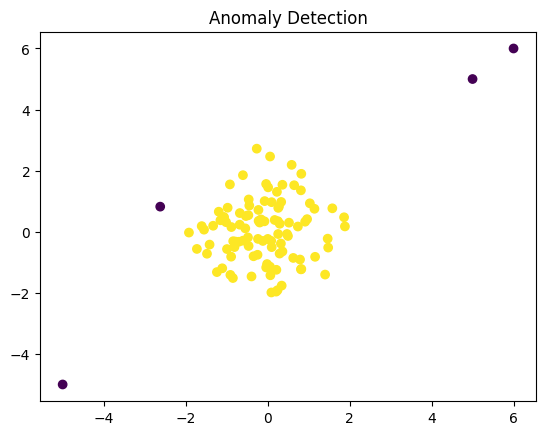

Anomalies:
[[-2.6197451  0.8219025]
 [ 5.         5.       ]
 [ 6.         6.       ]
 [-5.        -5.       ]]


In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

# Sample data
np.random.seed(42)
normal = np.random.randn(100, 2)
anomalies = np.array([[5, 5], [6, 6], [-5, -5]])

X = np.vstack([normal, anomalies])

# Train model
model = IsolationForest(contamination=0.03, random_state=42)
predictions = model.fit_predict(X)

# -1 = anomaly, 1 = normal
plt.scatter(X[:,0], X[:,1], c=predictions)
plt.title("Anomaly Detection")
plt.show()

print("Anomalies:")
print(X[predictions == -1])

#2. Introduction to Reinforcement Learning (Simple Reward Environment)

State=0, Action=1, Reward=-1
State=1, Action=-1, Reward=-1
State=0, Action=-1, Reward=-1
State=0, Action=1, Reward=-1
State=1, Action=1, Reward=-1
State=2, Action=-1, Reward=-1
State=1, Action=-1, Reward=-1
State=0, Action=-1, Reward=-1
State=0, Action=-1, Reward=-1
State=0, Action=1, Reward=-1
State=1, Action=1, Reward=-1
State=2, Action=1, Reward=-1
State=3, Action=-1, Reward=-1
State=2, Action=1, Reward=-1
State=3, Action=1, Reward=10
Goal Reached

State=0, Action=-1, Reward=-1
State=0, Action=1, Reward=-1
State=1, Action=1, Reward=-1
State=2, Action=1, Reward=-1
State=3, Action=1, Reward=10
Goal Reached

State=0, Action=-1, Reward=-1
State=0, Action=1, Reward=-1
State=1, Action=-1, Reward=-1
State=0, Action=-1, Reward=-1
State=0, Action=-1, Reward=-1
State=0, Action=1, Reward=-1
State=1, Action=1, Reward=-1
State=2, Action=-1, Reward=-1
State=1, Action=-1, Reward=-1
State=0, Action=1, Reward=-1
State=1, Action=1, Reward=-1
State=2, Action=1, Reward=-1
State=3, Action=1, Reward=10
G

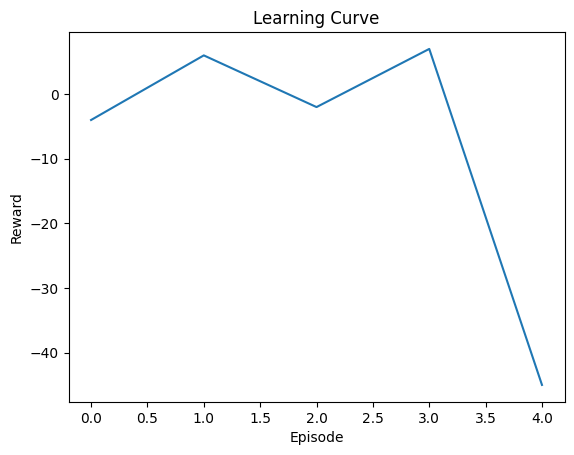

In [6]:
import random
import matplotlib.pyplot as plt

states = [0, 1, 2, 3, 4]
goal_state = 4

episode_rewards = []

for episode in range(5):
    state = 0
    total_reward = 0

    while state != goal_state:
        action = random.choice([1, -1])

        next_state = max(0, min(4, state + action))

        reward = 10 if next_state == goal_state else -1
        total_reward += reward
        print(f"State={state}, Action={action}, Reward={reward}")

        state = next_state

    print("Goal Reached\n")
    episode_rewards.append(total_reward)

plt.plot(episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Learning Curve")
plt.show()

#3. Markov Decision Process (MDP)

Current State: S2
Current State: Goal
Goal State Reached


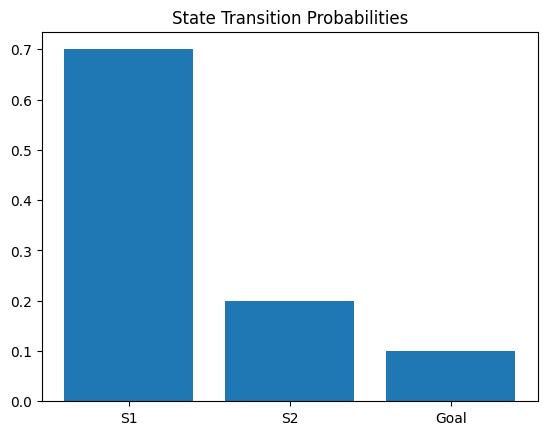

In [7]:
import numpy as np

states = ['S1', 'S2', 'Goal']

transition_matrix = np.array([
    [0.7, 0.3, 0.0],
    [0.2, 0.5, 0.3],
    [0.0, 0.0, 1.0]
])

current_state = 0

for step in range(10):
    current_state = np.random.choice(
        [0, 1, 2],
        p=transition_matrix[current_state]
    )

    print("Current State:", states[current_state])

    if current_state == 2:
        print("Goal State Reached")
        break
states = ["S1","S2","Goal"]
probs = [0.7,0.2,0.1]

plt.bar(states, probs)
plt.title("State Transition Probabilities")
plt.show()

#4. Q-Learning Algorithm

Learned Q-Table
[[ 54.84163388  62.171     ]
 [ 54.89316738  70.19      ]
 [ 62.05447572  79.1       ]
 [ 69.91216368  89.        ]
 [ 78.21246186 100.        ]
 [  0.           0.        ]]


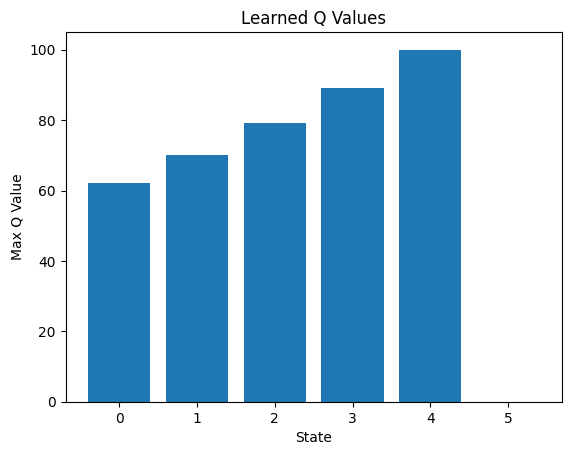

In [9]:
import numpy as np

# States and actions
n_states = 6
n_actions = 2

Q = np.zeros((n_states, n_actions))

alpha = 0.1
gamma = 0.9
epsilon = 0.1

goal_state = 5

for episode in range(1000):

    state = 0

    while state != goal_state:

        if np.random.rand() < epsilon:
            action = np.random.randint(n_actions)
        else:
            action = np.argmax(Q[state])

        next_state = min(state + 1, goal_state) if action == 1 else max(state - 1, 0)

        reward = 100 if next_state == goal_state else -1

        Q[state, action] = Q[state, action] + alpha * (
            reward +
            gamma * np.max(Q[next_state]) -
            Q[state, action]
        )

        state = next_state

print("Learned Q-Table")
print(Q)
max_q = np.max(Q, axis=1)

plt.bar(range(len(max_q)), max_q)
plt.xlabel("State")
plt.ylabel("Max Q Value")
plt.title("Learned Q Values")
plt.show()

#5. Deep Q-Network (DQN)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Predicted Q Values:
[[-0.21090126 -0.07219675]]
Selected Action: 1

Simulating a simple training process to generate loss_history...
Training simulation complete.


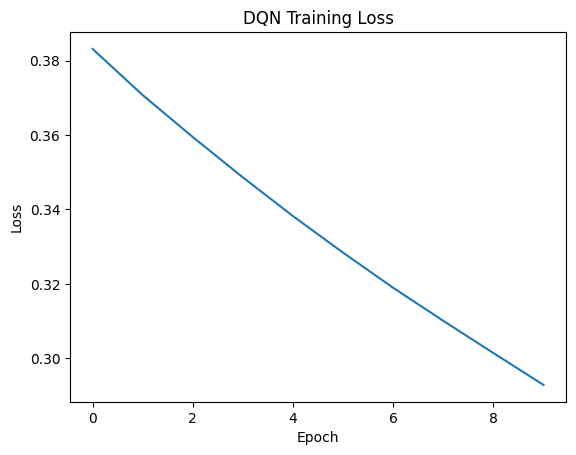

In [13]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

state_size = 4
action_size = 2

model = Sequential([
    Dense(24, input_dim=state_size, activation='relu'),
    Dense(24, activation='relu'),
    Dense(action_size, activation='linear')
])

model.compile(
    loss='mse',
    optimizer=Adam(learning_rate=0.001)
)

state = np.array([[1, 0, 0, 1]])

q_values = model.predict(state)

print("Predicted Q Values:")
print(q_values)

action = np.argmax(q_values[0])

print("Selected Action:", action)

num_training_steps = 10
dummy_states = np.random.rand(num_training_steps, state_size)

dummy_q_targets = np.random.rand(num_training_steps, action_size)

print("\nSimulating a simple training process to generate loss_history...")
history = model.fit(dummy_states, dummy_q_targets, epochs=num_training_steps, verbose=0)
loss_history = history.history['loss']
print("Training simulation complete.")

plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DQN Training Loss")
plt.show()